# Title

---
embed-resources: true
---

## Introduction

## Methods

In [18]:
# imports
import pandas as pd

# machine learning

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeClassifier
# preprocessing imports
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

### Data

In [2]:
# load data
wine_train = pd.read_parquet(
    "https://cs307.org/lab/data/wine-train.parquet",
)
wine_test = pd.read_parquet(
    "https://cs307.org/lab/data/wine-test.parquet",
)

Data Dictionary
Each observation in the train, test, and (hidden) production data contains information about a particular Portuguese “Vinho Verde” wine.

Vinho verde is a unique product from the Minho (northwest) region of Portugal. Medium in alcohol, is it particularly appreciated due to its freshness (specially in the summer).

Original and complete documentation for this data can be found in the original paper. Additionally, minimal documentation is provided by the UCI MLR.

Response
quality

[int64] the quality of the wine based on evaluation by a minimum of three sensory assessors (using blind tastes), which graded the wine in a scale that ranges from 0 (very bad) to 10 (excellent)
Features
color

[object] the (human perceivable) color of the wine, red or white
fixed acidity

[float64] grams of tartaric acid per cubic decimeter
volatile acidity

[float64] grams of acetic acid per cubic decimeter
citric acid

[float64] grams of citric acid per cubic decimeter
residual sugar

[float64] grams of residual sugar per cubic decimeter
chlorides

[float64] grams of sodium chloride cubic decimeter
free sulfur dioxide

[float64] milligrams of free sulfur dioxide per cubic decimeter
total sulfur dioxide

[float64] milligrams of total sulfur dioxide per cubic decimeter
density

[float64] the total density of the wine in grams per cubic centimeter
pH

[float64] the acidity of the wine measured using pH
sulphates

[float64] grams of potassium sulphate cubic decimeter
alcohol

[float64] percent alcohol by volume

,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
volatile acidity,1.000000,-0.385265,-0.184278,0.380014,-0.342452,-0.411439,0.277548,0.266339,0.218051,-0.031422,-0.267277
citric acid,-0.385265,1.000000,0.143739,0.038729,0.123602,0.194065,0.098102,-0.323129,0.075612,-0.007369,0.091446
residual sugar,-0.184278,0.143739,1.000000,-0.115574,0.395085,0.499370,0.558419,-0.269457,-0.174019,-0.365457,-0.040481
chlorides,0.380014,0.038729,-0.115574,1.000000,-0.185688,-0.274973,0.367868,0.062472,0.392246,-0.264195,-0.196897
free sulfur dioxide,-0.342452,0.123602,0.395085,-0.185688,1.000000,0.719292,0.019819,-0.147434,-0.171441,-0.177210,0.056792
total sulfur dioxide,-0.411439,0.194065,0.499370,-0.274973,0.719292,1.000000,0.026189,-0.248018,-0.264241,-0.264592,-0.037651
density,0.277548,0.098102,0.558419,0.367868,0.019819,0.026189,1.000000,0.007282,0.259032,-0.680396,-0.306238
pH,0.266339,-0.323129,-0.269457,0.062472,-0.147434,-0.248018,0.007282,1.000000,0.190834,0.119394,0.008376
sulphates,0.218051,0.075612,-0.174019,0.392246,-0.171441,-0.264241,0.259032,0.190834,1.000000,0.005466,0.047955
alcohol,-0.031422,-0.007369,-0.365457,-0.264195,-0.177210,-0.264592,-0.680396,0.119394,0.005466,1.000000,0.444678


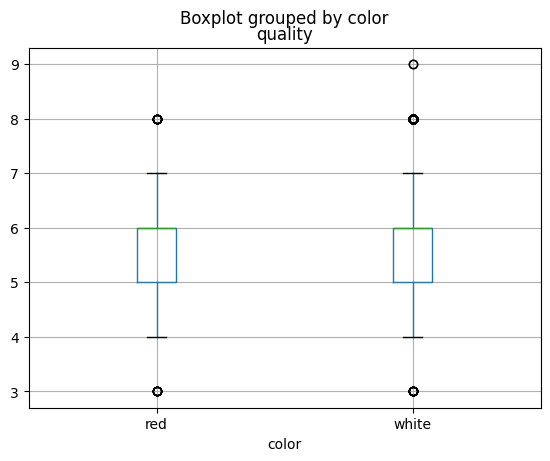

In [ ]:
# summary statistics
wine_train.iloc[:,1:12].corr()

In [53]:
wine_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
2556,7.6,0.23,0.64,12.9,0.033,54.0,170.0,0.99800,3.00,0.53,8.8,5,white
1237,NaN,0.75,0.01,2.2,0.059,11.0,18.0,0.99242,3.39,0.40,NaN,6,red
303,7.4,0.67,0.12,1.6,0.186,5.0,21.0,0.99600,3.39,0.54,9.5,5,red
1583,6.4,0.18,0.74,NaN,0.046,54.0,168.0,0.99780,3.58,0.68,10.1,5,white
4697,6.7,0.35,0.32,9.0,0.032,29.0,113.0,0.99188,3.13,0.65,12.9,7,white
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,6.6,0.32,0.22,16.7,0.046,38.0,133.0,0.99790,3.22,0.67,10.4,6,white
905,9.2,0.58,0.20,3.0,0.081,15.0,115.0,0.99800,3.23,0.59,9.5,5,red
247,8.2,0.60,0.17,2.3,0.072,11.0,73.0,0.99630,3.20,0.45,9.3,5,red
2707,6.5,0.23,0.36,16.3,0.038,43.0,133.0,0.99924,3.26,0.41,8.8,5,white


In [ ]:
# exploratory visualization

### Models

In [11]:
# process data for ML
# create X and y for train
X_train = wine_train.drop("quality", axis=1)
y_train = wine_train["quality"]

# create X and y for test
X_test = wine_test.drop("quality", axis=1)
y_test = wine_test["quality"]

In [78]:
numeric_features = ['volatile acidity', 'chlorides', 'density', 'alcohol','citric acid','total sulfur dioxide','sulphates','fixed acidity','residual sugar','free sulfur dioxide','pH']
categorical_features = ['color']
features = numeric_features + categorical_features
target = "quality"

In [79]:
# train models
dt = DecisionTreeRegressor()
dtc = DecisionTreeClassifier()
# define preprocessing for numeric features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
)

# define preprocessing for categorical features
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="infrequent_if_exist"),
)

# create general preprocessor
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    remainder="drop",
)
# define the parameter grid
# check error

param_grid = {
    
    "decisiontreeclassifier__min_samples_split": [50, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600],
}

# create the pipeline
pipeline = make_pipeline(
    preprocessor,
    dtc,
)

# create the grid search
mod = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
)

# fit the grid search
mod.fit(X_train, y_train)

# print the best parameters and the corresponding score
print(f"Best Parameters: {mod.best_params_}")
print(f"Best Cross-Validated MAE: {mod.best_score_}")

c:\Users\changrong Wu\OneDrive\桌面\cs307\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'decisiontreeclassifier__min_samples_split': 500}
Best Cross-Validated MAE: -0.5248975978894752


In [80]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
# train models
knn = KNeighborsRegressor()
# define preprocessing for numeric features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

# define preprocessing for categorical features
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="infrequent_if_exist"),
)

# create general preprocessor
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    remainder="drop",
)
# define the parameter grid
param_grid = {
    "kneighborsregressor__n_neighbors": [1, 5, 10, 15, 20, 25],
    "kneighborsregressor__p": [1, 2],
}

# create the pipeline
pipeline = make_pipeline(
    preprocessor,
    knn,
)

# create the grid search
mod = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
)

# fit the grid search
mod.fit(X_train, y_train)

# print the best parameters and the corresponding score
print(f"Best Parameters: {mod.best_params_}")
print(f"Best Cross-Validated RMSE: {mod.best_score_}")

Best Parameters: {'kneighborsregressor__n_neighbors': 1, 'kneighborsregressor__p': 1}
Best Cross-Validated RMSE: -0.49363139868555034


## Results

In [81]:
# report model metrics
mean_absolute_error(mod.predict(X_test), y_test)

0.4634615384615385

In [ ]:
# summary figure

In [68]:
# serialize model
from joblib import dump
dump(mod, "wine.joblib")

['wine.joblib']

## Discussion